### DIBs VIBS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports completados")

✓ Imports completados


In [3]:
from pathlib import Path
import sys

cwd = Path().resolve()
for p in [cwd] + list(cwd.parents):
    if (p / "utils").is_dir():
        sys.path.insert(0, str(p))
        break

from utils.download_data_binance import DowloadDataBinance as dt 
from utils.info_bars import InfoBars as ib 

In [4]:
data_path = '../data/raw'
info_bars = ib(data_path)
download_data = dt(data_path)

In [5]:
df = download_data.download_trades_binance(
    symbol='BTCUSDT',
    hours=120,  
    max_trades=300000
)

download_data.show_info(df)

Descargando trades de BTCUSDT...
Trades: 200,000 | Iter: 200
✓ Descargados: 200,000 trades
Guardado en: ../data/rawBTCUSDT_trades_20251024_224934.csv

INFORMACIÓN DE LOS DATOS
Total trades: 73,134
Período: 2025-10-20 03:47:54.051000 a 2025-10-20 06:53:09.659000
Duración: 3.1 horas

Primeros 5 trades:
                timestamp      price  quantity  dollar_value
0 2025-10-20 03:47:54.051  109166.27   0.00022     24.016579
1 2025-10-20 03:47:54.279  109166.27   0.00090     98.249643
2 2025-10-20 03:47:54.505  109166.26   0.01400   1528.327640
3 2025-10-20 03:47:54.530  109166.26   0.00500    545.831300
4 2025-10-20 03:47:54.731  109166.27   0.04731   5164.656234

Estadísticas:
                           timestamp          price      quantity  \
count                          73134   73134.000000  73134.000000   
mean   2025-10-20 05:11:05.416631040  110571.813764      0.023363   
min       2025-10-20 03:47:54.051000  109166.250000      0.000010   
25%       2025-10-20 04:10:29.028000  110

In [6]:
tib_bars = info_bars.get_tibs(df)

In [14]:
print(len(tib_bars))

29


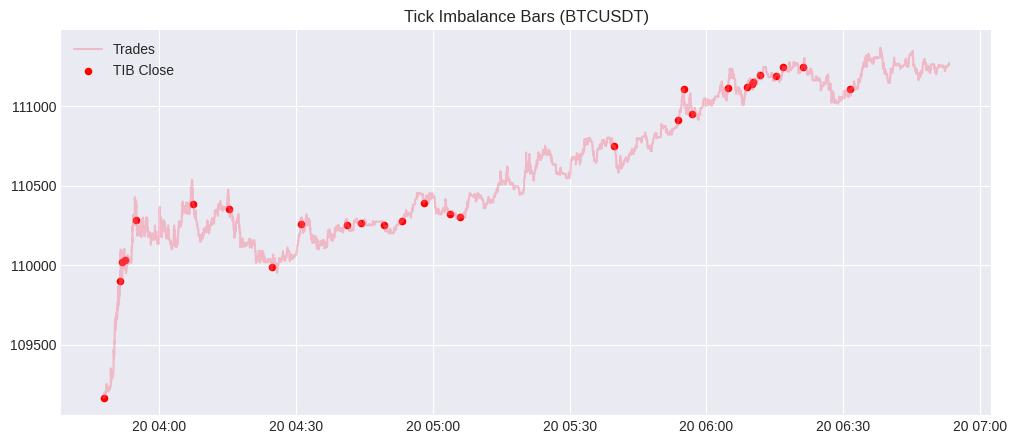

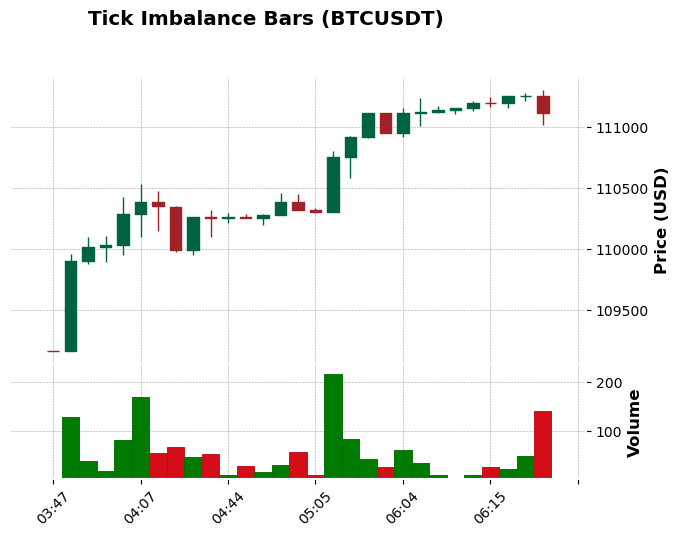

In [13]:
info_bars.plot_stops(df, tib_bars)
tib_bars.set_index('close_time', inplace=True)
info_bars.candle_bars(tib_bars)